In [1]:
from utils import FSL105, Video2Landmarks, filter_detected, interpolate_missing_data
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.patches as patches


# goal:
## normalize pose
## normalize hands

In [2]:
POSE_CONNECTIONS = frozenset([
    (0,1),(1,2),(2,3),(3,7),(0,4),(4,5),(5,6),(6,8),
    (9,10),(11,12),(11,13),(13,15),(15,17),(15,19),(15,21),(17,19),
    (12,14),(14,16),(16,18),(16,20),(16,22),(18,20),
    (11,23),(12,24),(23,24),(23,25),(24,26),(25,27),(26,28),
    (27,29),(28,30),(29,31),(30,32),(27,31),(28,32)
])

HAND_CONNECTIONS = frozenset([
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),
    (0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20),
    (5,9),(9,13),(13,17)
])

def landmarks_to_array(landmark_list, expected_count, flatten:bool=False):
        if landmark_list:
            return np.array([[lm.x, lm.y, lm.z] for lm in landmark_list]).flatten() if flatten else np.array([[lm.x, lm.y, lm.z] for lm in landmark_list])
        return np.zeros(expected_count*3)

In [ ]:
folder_path = './clips'
mp_model_path = './resources/holistic_landmarker.task'
landmark_include_ind = 3
fsl_data = FSL105(folder_path)
fsl_data = fsl_data.load_data(selected_classes=10)

vid2landmarks = Video2Landmarks(model_path=mp_model_path, 
                                    landmark_type='relative',
                                    landmark_include_ind=landmark_include_ind,
                                    display_vid=True,
                                    remove_duplicate_landmarks=False)

In [171]:
landmarks, result = vid2landmarks.transform(fsl_data['path'][10])

In [172]:
landmarks.shape

(244, 225)

#### Initial Cleaning

- Remove frames with no hands detected
- Interpolate misdetected hand locations

In [160]:
landmarks = landmarks.reshape(landmarks.shape[0], -1, 3)
landmarks = filter_detected(landmarks)
landmarks = interpolate_missing_data(landmarks)

In [170]:
landmarks.shape

(114, 75, 3)

#### Pose Landmark Scaling Logic

##### Explained

In [6]:
pose = landmarks_to_array(result.pose_landmarks, expected_count=33, flatten=False)

head_unit = math.dist(pose[11,:2], pose[12,:2])/2  # 1/2 dist(left -> right shoulder)
head_unit

0.12125392938996062

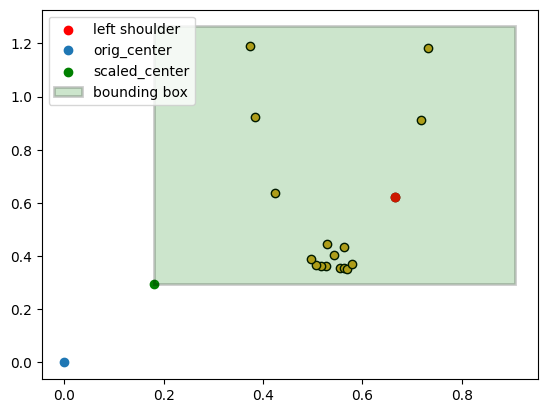

In [101]:
fig = plt.figure()
ax = fig.add_subplot()

rect = patches.Rectangle(
    (pose[0,0]-3*head_unit,
     pose[2,1]-0.5*head_unit),  # (bottom left)
    6*head_unit, 8*head_unit,
    linewidth=2,
    edgecolor='k',
    facecolor='g',
    alpha=0.2,
    label='bounding box'
)
x = pose[:, 0]
y = pose[:, 1]

ax.scatter(x[:17],y[:17], color='goldenrod', edgecolors='black')
ax.scatter(pose[11,0], pose[11,1], color='red', label='left shoulder')
ax.scatter([0],[0], label='orig_center')
ax.scatter(pose[0,0]-3*head_unit,[pose[2,1]-0.5*head_unit], color='green', label='scaled_center')
ax.add_patch(rect)

plt.legend()
plt.show()

In [102]:
# force bottom left of bounding box as center
x0 = pose[0,0] - 3*head_unit        # 6 head_units horizontal, centered at nose
y0 = pose[2,1] - 0.5*head_unit  # # 0.5 head_units upward from eye, then 7 head_units vertical

# scale points
pose[:,0] = pose[:,0] - x0
pose[:,1] = pose[:,1] - y0

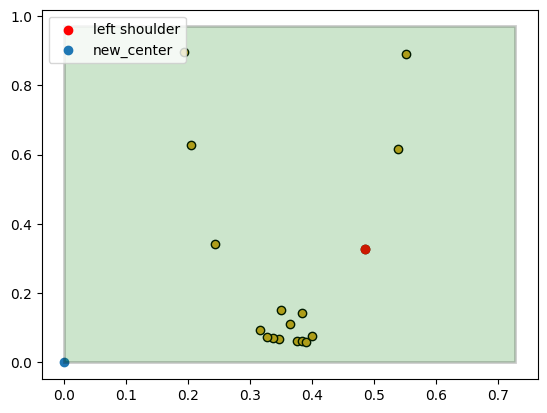

In [104]:
fig = plt.figure()
ax = fig.add_subplot()

rect = patches.Rectangle(
    (0,0),  # (bottom left)
    6*head_unit, 8*head_unit,
    linewidth=2,
    edgecolor='k',
    facecolor='g',
    alpha=0.2
)
x = pose[:, 0]
y = pose[:, 1]

ax.scatter(x[:17],y[:17], color='goldenrod', edgecolors='black')
ax.scatter(pose[11,0], pose[11,1], color='red', label='left shoulder')
ax.scatter([0],[0], label='new_center')
ax.add_patch(rect)

plt.legend(loc='upper left')
plt.show()

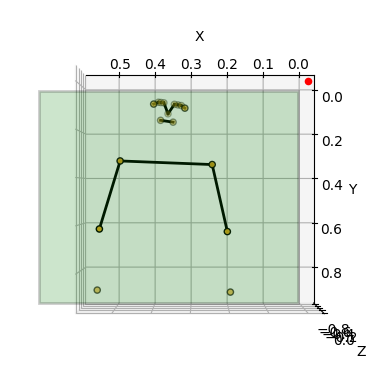

In [168]:
import mpl_toolkits.mplot3d.art3d as art3d

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# bounding box
rect = patches.Rectangle(
    (0,0),  # (bottom left)
    6*head_unit, 8*head_unit,
    linewidth=2,
    edgecolor='k',
    facecolor='g',
    alpha=0.2
)


# Extract X, Y, Z columns from the N x 3 array
x = pose[:17, 0]
y = pose[:17, 1]
z = pose[:17, 2]

ax.scatter(x, y, z, color='goldenrod', edgecolors='black')
ax.scatter([0],[0],[0], color='red')
for ind in POSE_CONNECTIONS:
    if ind[0] > 14 or ind[1] > 14:
        continue
    points = np.concat([pose[ind[0]], pose[ind[1]]], axis=0).reshape(2,3)  # 2x3 (x,y,z)
    points = points.transpose()
    ax.plot(points[0], points[1], points[2], color='black', linewidth=2)
ax.add_patch(rect)
art3d.pathpatch_2d_to_3d(rect, z=-1, zdir="z")


ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.view_init(elev=90, azim=90, roll=0)
plt.show()

##### Implement

In [ ]:
def translate_pose_landmarks(pose_landmarks:np.ndarray) -> np.ndarray:
    """
    Creates a bounding box for `pose_landmarks` for each frame.
    A `head_unit` is defined as head height, estimated as half the distance between shoulders.
    Bounding box size: 6`head_units` wide x 8`head_units` tall
    Top edge of bounding box is 0.5`head_units` upright from left eye. Horizontal center is the nose.

    Origin is set as bottom left corner of the bounding box. Pose landmarks are shifted with respect to
    new origin.
    

    :param pose_landmarks: shape = nframes x 33 landmarks x 3 dimensions
    :return translated_pose_landmarks:
    """

    for f in range(pose_landmarks.shape[0]):
        # calculate head_unit: 1/2 dist(left -> right shoulder; x & y coords)
        head_unit = math.dist(pose_landmarks[f,11,:2], pose_landmarks[f,12,:2])/2
        
        # calculate new origin (bottom left corner of bbox)
        x0 = pose_landmarks[f,0,0] - 3*head_unit      # 6 head_units horizontal, centered at nose
        y0 = pose_landmarks[f,2,1] - 0.5*head_unit    # 0.5 head_units upward from eye

        # scale points
        pose_landmarks[f,:,0] = pose_landmarks[f,:,0] - x0
        pose_landmarks[f,:,1] = pose_landmarks[f,:,1] - y0

    return pose_landmarks

In [110]:
translate_pose_landmarks(landmarks[:,21*2:])

array([[[ 3.53079869e-01,  1.11063920e-01, -7.78646231e-01],
        [ 3.61934139e-01,  6.19943363e-02, -7.36942291e-01],
        [ 3.70281591e-01,  5.88466448e-02, -7.37003446e-01],
        ...,
        [ 3.48303809e-01,  1.77797540e+00,  2.76285529e-01],
        [ 4.53995480e-01,  1.88437017e+00,  1.61619380e-01],
        [ 3.52218999e-01,  1.84750851e+00, -4.16557537e-04]],

       [[ 3.51756867e-01,  1.10418468e-01, -7.93940723e-01],
        [ 3.60614057e-01,  6.19423979e-02, -7.52202272e-01],
        [ 3.69225796e-01,  5.86261445e-02, -7.52177179e-01],
        ...,
        [ 3.45392938e-01,  1.75833461e+00,  2.71000803e-01],
        [ 4.51794084e-01,  1.86507603e+00,  1.42407358e-01],
        [ 3.50317295e-01,  1.82966277e+00, -3.40959430e-03]],

       [[ 3.49931706e-01,  1.09697042e-01, -7.78425813e-01],
        [ 3.58618726e-01,  6.16278631e-02, -7.39625573e-01],
        [ 3.67466618e-01,  5.83219511e-02, -7.39686549e-01],
        ...,
        [ 3.34813286e-01,  1.75071895e+00,

#### Hand Landmark Scaling Logic

For each hand, in each frame, find a *square bounding box* around the hand's landmarks with a *10% margin*. Then min-max normalize every landmark into the box so it maps to $[-1,1] \times [-1,1]$ with center of the bounding box as the the origin.

What this does:
- Translation invariance - doesn't matter where the hand is in the camera frame
- Scale invariance - doesn't matter how close/far the hand is from the camera.

##### Explained

In [161]:
left_hand_landmarks = landmarks[:, :21]
right_hand_landmarks = landmarks[:, 21:21*2]

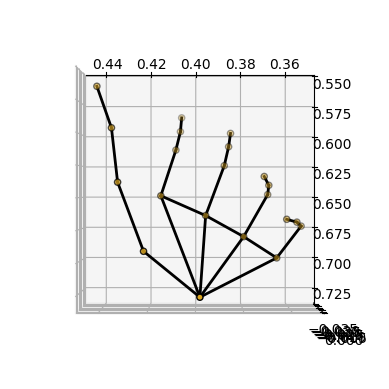

In [162]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

hands = right_hand_landmarks[105,:]
ax.scatter(hands[:,0], hands[:,1], hands[:,2], c='goldenrod', edgecolors='black')
for ind in HAND_CONNECTIONS:
    points = np.concat([hands[ind[0]], hands[ind[1]]], axis=0).reshape(2,3)  # 2x3 (x,y,z)
    points = points.transpose()
    ax.plot(points[0], points[1], points[2], color='black', linewidth=2)

ax.view_init(elev=90, azim=90, roll=0)
plt.show()

In [163]:
print(f"X coords range: {min(hands[:,0])} - {max(hands[:,0])}")
print(f"Y coords range: {min(hands[:,1])} - {max(hands[:,1])}")

X coords range: 0.353781521320343 - 0.44261083006858826
Y coords range: 0.5611281394958496 - 0.7257637977600098


In [165]:
# defining bounding box

min_x, max_x = min(hands[:,0]), max(hands[:,0])
min_y, max_y = min(hands[:,1]), max(hands[:,1])
width, height = max_x - min_x, max_y - min_y
if width > height:
    # new width = width + 2*delta_x (pad left & right)
    delta_x = 0.1*width
    delta_y = delta_x + ((width-height) / 2)
else:
    delta_y = 0.1*height
    delta_x = delta_y + ((height-width) / 2)

# define box corner
top_left = (min_x - delta_x, min_y - delta_y)
bottom_right = (max_x + delta_x, max_y + delta_y)

# set center of bounding box as origin
center = ((top_left[0] + bottom_right[0])/2,
          (top_left[1] + bottom_right[1])/2)

# set scale range of values to [-1,1]
half_width = (bottom_right[0] - top_left[0])/2
half_height = (bottom_right[1] - top_left[1])/2

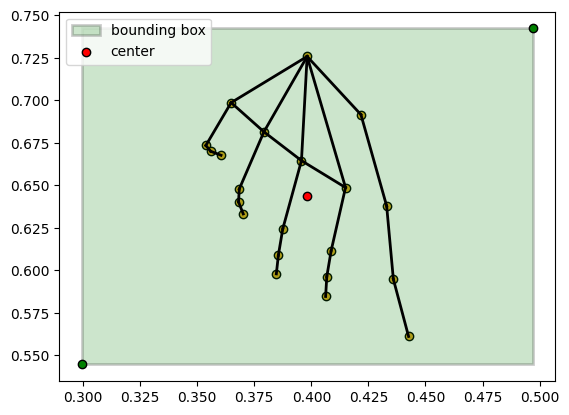

In [166]:
fig = plt.figure()
ax = fig.add_subplot()

hands = right_hand_landmarks[105,:]
ax.scatter(hands[:,0], hands[:,1], c='goldenrod', edgecolors='black')
for ind in HAND_CONNECTIONS:
    points = np.concat([hands[ind[0]], hands[ind[1]]], axis=0).reshape(2,3)  # 2x3 (x,y,z)
    points = points.transpose()
    ax.plot(points[0], points[1], color='black', linewidth=2)

rect = patches.Rectangle(
    top_left,
    width+2*delta_x, height+2*delta_y,
    linewidth=2,
    edgecolor='k',
    facecolor='g',
    alpha=0.2,
    label='bounding box'
)
ax.add_patch(rect)

ax.scatter(top_left[0], top_left[1], c='g', edgecolors='k')
ax.scatter(bottom_right[0], bottom_right[1], c='g', edgecolors='k')
ax.scatter(center[0], center[1], c='r', edgecolors='k',
           label='center')
plt.legend()
plt.show()

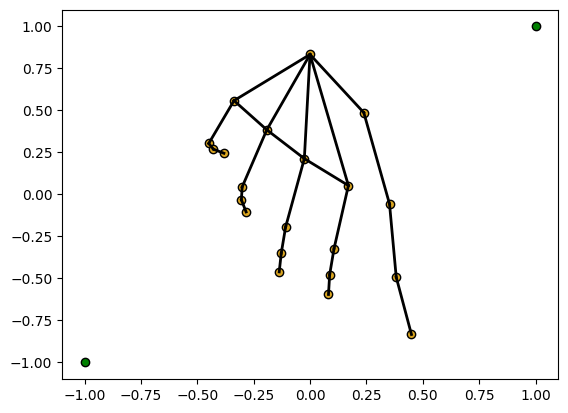

In [167]:
normalized_x = (hands[:,0] - center[0])/half_width
normalized_y = (hands[:,1] - center[1])/half_height

normalized_hands = np.column_stack([normalized_x, normalized_y])

fig = plt.figure()
ax = fig.add_subplot()

for ind in HAND_CONNECTIONS:
    points = np.concat([normalized_hands[ind[0]], normalized_hands[ind[1]]], axis=0).reshape(2,2)
    points = points.transpose()
    ax.plot(points[0], points[1], color='black', linewidth=2)
ax.scatter(normalized_x, normalized_y, c='goldenrod', edgecolors='black')


ax.scatter((top_left[0]-center[0])/half_width, (top_left[1]-center[1])/half_height, c='g', edgecolors='k')
ax.scatter((bottom_right[0]-center[0])/half_width, (bottom_right[1]-center[1])/half_height, c='g', edgecolors='k')

# plt.legend()
plt.xlim([-1.1,1.1])
plt.ylim([-1.1,1.1])
plt.show()

##### Implementation

In [ ]:
def translate_hand_landmarks(hand_landmarks:np.ndarray, padding:float=0.1) -> np.ndarray:
    """
    A smallest possible square is defined from the X and Y range of `hand_landmarks`.
    A `padding`% is added to each side which defines the edge of the bounding box.

    The origin is now defined as the center of the bounding box. Hand landmarks are shifted with respect to
    new origin. Shifted `hand_landmarks` coordinates are then each scaled to [-1,1].
    
    If hand is missing (all 0s), retain landmarks as 0s.

    :param hand_landmarks: shape = nframes x 21 landmarks x 3 dimensions
    :return translated_hand_landmarks:
    """

    for f in range(hand_landmarks.shape[0]):
        # define smallest possible square
        min_x, max_x = min(hand_landmarks[f,:,0]), max(hand_landmarks[f,:,0])
        min_y, max_y = min(hand_landmarks[f,:,1]), max(hand_landmarks[f,:,1])
        
        width, height = max_x - min_x, max_y - min_y
        # new width = width + 2*delta_x (pad left & right)
        # new height = height + 2*delta_y (pad top & bottom)
        if width > height:
            
            delta_x = padding*width
            delta_y = delta_x + ((width-height) / 2)
        else:
            delta_y = padding*height
            delta_x = delta_y + ((height-width) / 2)

        # define bounding box corner    
        top_left = (min_x - delta_x, min_y - delta_y)
        bottom_right = (max_x + delta_x, max_y + delta_y)

        # define center of bounding box as origin
        center = ((top_left[0] + bottom_right[0])/2,
                (top_left[1] + bottom_right[1])/2)

        # set scale range of values to [-1,1]
        half_width = (bottom_right[0] - top_left[0])/2
        half_height = (bottom_right[1] - top_left[1])/2

        # scale landmarks
        hand_landmarks[f,:,0] = (hand_landmarks[f,:,0] - center[0])/half_width if half_width !=0 else hand_landmarks[f,:,0]
        hand_landmarks[f,:,1] = (hand_landmarks[f,:,1] - center[1])/half_height if half_height !=0 else hand_landmarks[f,:,1]

    return hand_landmarks        

In [98]:
left_hand_landmarks = landmarks[:, :21]
right_hand_landmarks = landmarks[:, 21:21*2]

translate_hand_landmarks(right_hand_landmarks)

array([[[-2.32003105e-01,  7.30955794e-01, -1.08063965e-07],
        [-1.51821300e-01,  2.82050995e-01, -1.71780994e-03],
        [ 3.92195438e-03, -1.74538505e-01, -5.91908954e-03],
        ...,
        [ 1.58578264e-01,  8.00261735e-01, -3.32708582e-02],
        [ 1.57803621e-01,  8.26817777e-01, -2.85406727e-02],
        [ 9.73298319e-02,  8.33333333e-01, -2.57731937e-02]],

       [[-1.30882467e-01,  6.16696212e-01, -1.11142899e-08],
        [-9.40517188e-03,  1.96369665e-01, -5.13768196e-03],
        [ 9.26485355e-02, -1.84160319e-01, -1.01691093e-02],
        ...,
        [-2.38307322e-02,  8.19776487e-01, -2.44253092e-02],
        [ 7.51136402e-03,  8.33333333e-01, -2.30459291e-02],
        [ 3.01476147e-02,  7.84566100e-01, -2.19610892e-02]],

       [[-3.02509948e-01,  8.33333333e-01,  1.14449222e-07],
        [-2.29020132e-01,  3.20340952e-01, -2.85341917e-03],
        [-4.22341479e-02, -1.59725439e-01, -6.08965289e-03],
        ...,
        [ 1.58798419e-01,  5.65258420e-01,